In [1]:
# =========================
# SETUP + DATA LOADING
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# -------------------------
# Create export folder
# -------------------------
os.makedirs("reports/exported_charts", exist_ok=True)

# -------------------------
# Load datasets (Mutual Fund Analytics)
# -------------------------
funds = pd.read_csv("data/raw/01_fund_master.csv")
nav = pd.read_csv("data/raw/02_nav_history.csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("data/raw/05_category_inflows.csv")
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("data/raw/08_investor_transactions.csv")
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

# -------------------------
# DATA QUALITY CHECK
# -------------------------

print("✅ DATA LOADED SUCCESSFULLY")
print("\n📊 Dataset Shapes:")
print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)

# -------------------------
# CHECK MISSING VALUES
# -------------------------
print("\n📊 Missing Values Summary (Quick Check):")
for name, df in {
    "Funds": funds,
    "NAV": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}.items():
    print(f"{name}: {df.isnull().sum().sum()} missing values")

✅ DATA LOADED SUCCESSFULLY

📊 Dataset Shapes:
Funds: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)

📊 Missing Values Summary (Quick Check):
Funds: 0 missing values
NAV: 0 missing values
AUM: 0 missing values
SIP: 12 missing values
Category: 0 missing values
Folio: 0 missing values
Performance: 0 missing values
Transactions: 0 missing values
Holdings: 0 missing values
Benchmark: 0 missing values


In [2]:
# Convert date columns to proper datetime format

nav["date"] = pd.to_datetime(nav["date"], errors="coerce")
sip["month"] = pd.to_datetime(sip["month"], errors="coerce")
category["month"] = pd.to_datetime(category["month"], errors="coerce")
folio["month"] = pd.to_datetime(folio["month"], errors="coerce")

# Merge NAV with fund master data

nav_merged = nav.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Sort for time-series consistency

nav_merged = nav_merged.sort_values(by="date")

# Basic validation

print("Data cleaning complete")

print("\nDate range NAV:", nav_merged["date"].min(), "→", nav_merged["date"].max())
print("Date range SIP:", sip["month"].min(), "→", sip["month"].max())

print("\nMissing values total:", nav_merged.isnull().sum().sum())

Data cleaning complete

Date range NAV: 2022-01-03 00:00:00 → 2026-05-29 00:00:00
Date range SIP: 2022-01-01 00:00:00 → 2025-12-01 00:00:00

Missing values total: 0


In [3]:
# NAV trend analysis across schemes

fig_nav = px.line(
    nav_merged,
    x="date",
    y="nav",
    color="scheme_name",
    title="NAV Trend Across Mutual Fund Schemes"
)

# Highlight market phases

fig_nav.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.08,
    annotation_text="Bull Phase"
)

fig_nav.add_vrect(
    x0="2024-01-01", x1="2024-06-30",
    fillcolor="red", opacity=0.08,
    annotation_text="Correction Phase"
)

fig_nav.update_layout(template="plotly_dark")

fig_nav.show()

# Save output
fig_nav.write_image("reports/exported_charts/nav_trend.png")

NAV trends show strong cyclical behavior with a major growth phase in 2023 followed by a correction period in 2024, indicating sensitivity to macroeconomic conditions.

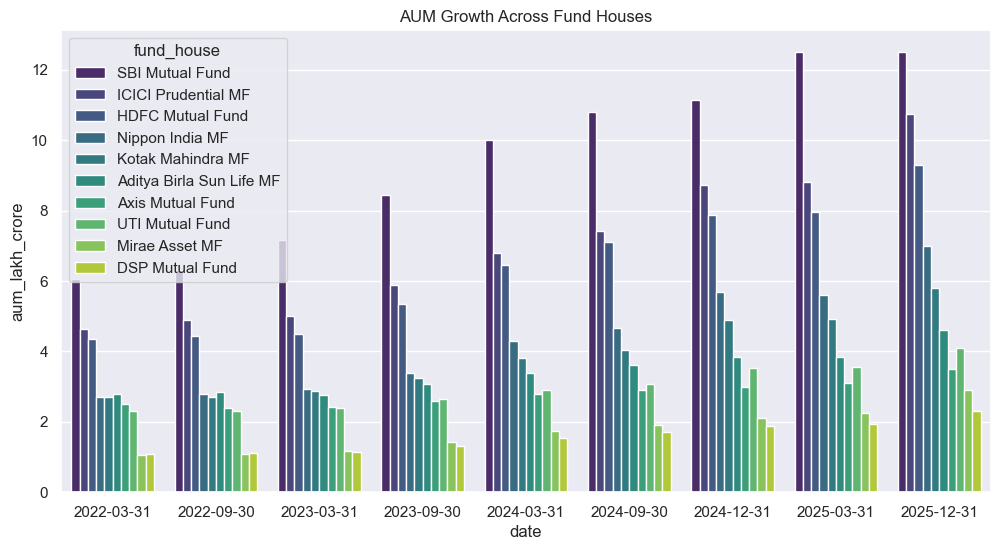

In [4]:
# AUM analysis across fund houses

plt.figure(figsize=(12,6))
sns.set_theme(style="darkgrid")

year_col = aum.columns[0]
house_col = aum.columns[1]
aum_col = aum.columns[2]

sns.barplot(
    data=aum,
    x=year_col,
    y=aum_col,
    hue=house_col,
    palette="viridis"
)

plt.title("AUM Growth Across Fund Houses")

# Save chart
plt.savefig("reports/exported_charts/aum_growth.png", dpi=300, bbox_inches="tight")

plt.show()

AUM data shows strong concentration among leading fund houses, indicating dominance of large AMCs in asset accumulation over time.

In [5]:
# SIP inflow trend analysis

fig_sip = px.line(
    sip,
    x=sip.columns[0],
    y=sip.columns[1],
    markers=True,
    title="Monthly SIP Inflow Trend"
)

fig_sip.update_layout(template="plotly_dark")

fig_sip.show()

# Save output
fig_sip.write_image("reports/exported_charts/sip_inflow.png")

SIP inflows show consistent upward momentum, indicating increasing retail investor participation and disciplined long-term investing behavior.

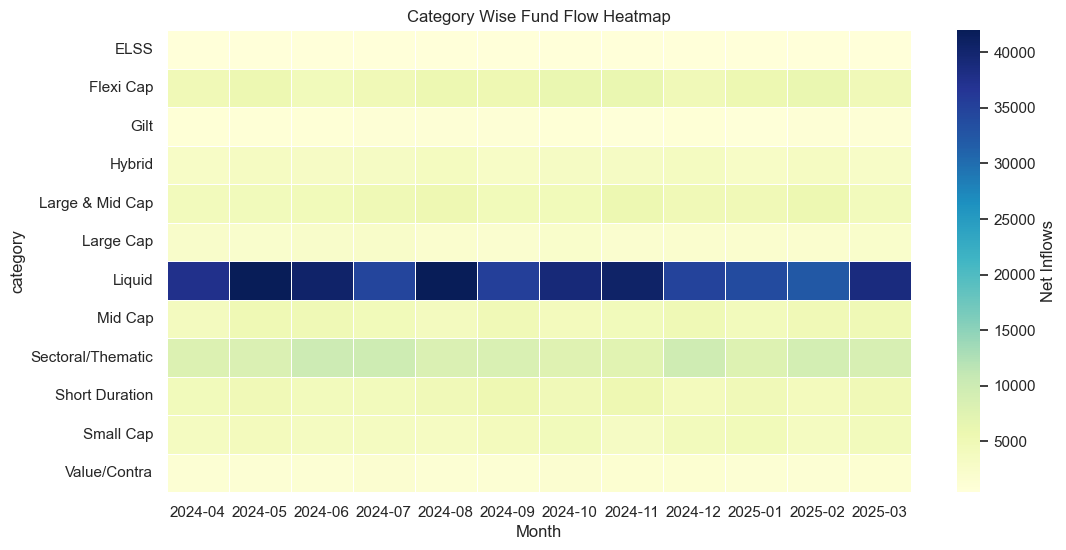

In [6]:
# Category inflow heatmap (sector-wise money flow pattern)

cat = category.copy()

# Convert month properly for clean timeline labels
cat["Month"] = pd.to_datetime(cat[category.columns[0]]).dt.strftime("%Y-%m")

# Create pivot table (Category vs Time)
heatmap_data = cat.pivot(
    index=category.columns[1],
    columns="Month",
    values=category.columns[2]
)

plt.figure(figsize=(12,6))
sns.set_theme(style="white")

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "Net Inflows"}
)

plt.title("Category Wise Fund Flow Heatmap")

# Save output
plt.savefig("reports/exported_charts/category_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Category inflows show clear sector rotation patterns, indicating that investor capital shifts dynamically across categories based on market cycles and macro conditions.

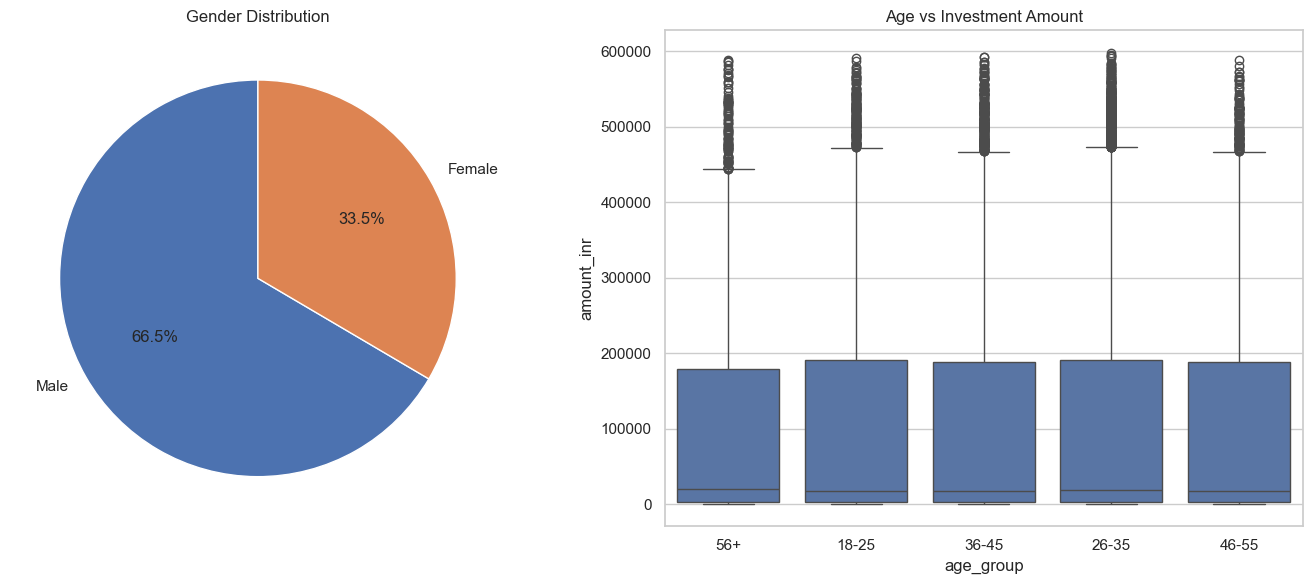

In [7]:
# Investor demographics analysis

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------
# GENDER DISTRIBUTION
# -------------------------
gender_col = [c for c in transactions.columns if "gender" in c.lower() or "sex" in c.lower()][0]
gender_data = transactions[gender_col].value_counts()

axes[0].pie(
    gender_data,
    labels=gender_data.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Gender Distribution")

# -------------------------
# AGE vs INVESTMENT BEHAVIOR
# -------------------------
age_col = [c for c in transactions.columns if "age" in c.lower()][0]
amt_col = [c for c in transactions.columns if "amount" in c.lower() or "sip" in c.lower()][0]

sns.boxplot(
    data=transactions,
    x=age_col,
    y=amt_col,
    ax=axes[1]
)

axes[1].set_title("Age vs Investment Amount")

plt.tight_layout()

# Save output
plt.savefig("reports/exported_charts/demographics.png", dpi=300, bbox_inches="tight")

plt.show()

Retail investor base shows balanced gender participation, while investment size varies significantly across age groups, with higher contributions typically seen in mature age brackets.

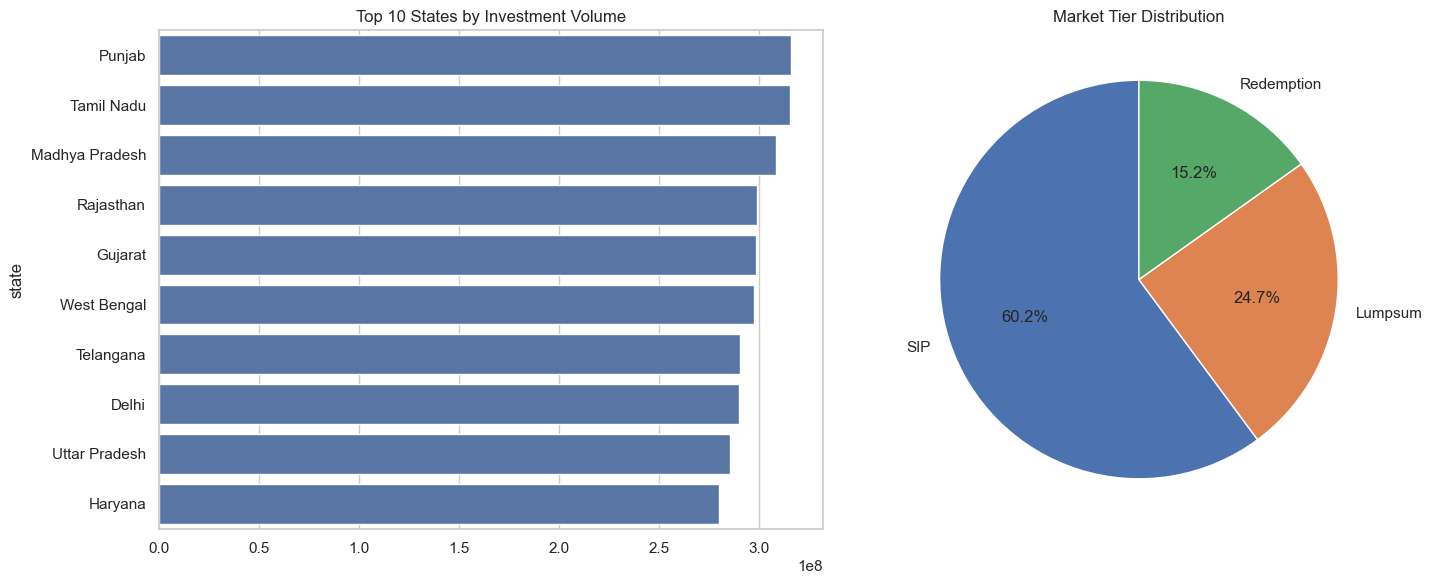

In [8]:
# Geography-based investment analysis

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------
# TOP STATES BY INVESTMENT
# -------------------------
state_col = [c for c in transactions.columns if "state" in c.lower()][0]
amt_col = [c for c in transactions.columns if "amount" in c.lower() or "sip" in c.lower()][0]

state_data = transactions.groupby(state_col)[amt_col].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=state_data.values,
    y=state_data.index,
    ax=axes[0]
)

axes[0].set_title("Top 10 States by Investment Volume")

# -------------------------
# TIER / CITY CATEGORY SPLIT
# -------------------------
tier_col = [c for c in transactions.columns 
            if "tier" in c.lower() or "city" in c.lower() or "type" in c.lower()][0]

tier_data = transactions[tier_col].value_counts()

axes[1].pie(
    tier_data,
    labels=tier_data.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("Market Tier Distribution")

plt.tight_layout()

# Save output
plt.savefig("reports/exported_charts/geography.png", dpi=300, bbox_inches="tight")

plt.show()

Investment activity is highly concentrated in urban states, while Tier-1 cities dominate inflows, indicating strong urban bias in mutual fund penetration.

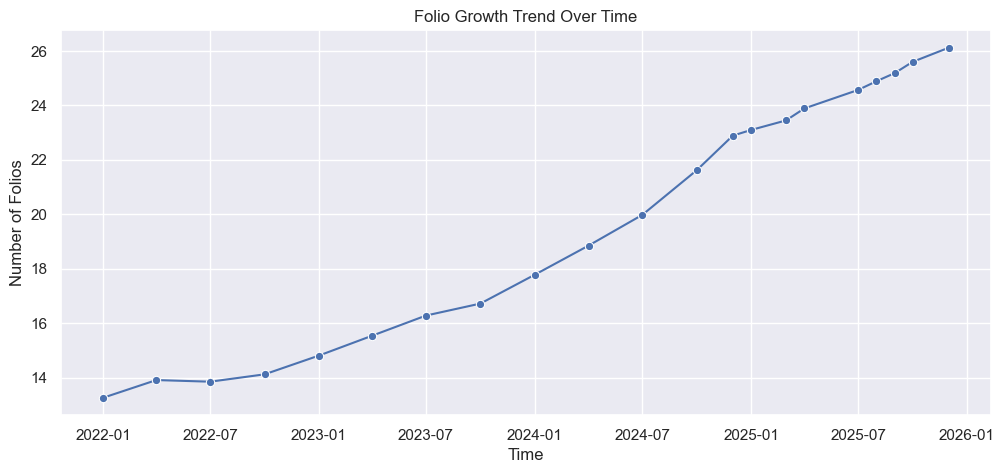

In [9]:
# Folio growth trend analysis

sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 5))

folio_date_col = folio.columns[0]
folio_value_col = folio.columns[1]

sns.lineplot(
    data=folio,
    x=folio_date_col,
    y=folio_value_col,
    marker="o"
)

plt.title("Folio Growth Trend Over Time")

plt.xlabel("Time")
plt.ylabel("Number of Folios")

# Save output
plt.savefig("reports/exported_charts/folio_growth.png", dpi=300, bbox_inches="tight")

plt.show()

Folio count shows consistent upward growth, indicating increasing mutual fund adoption and expanding retail investor base in the market.

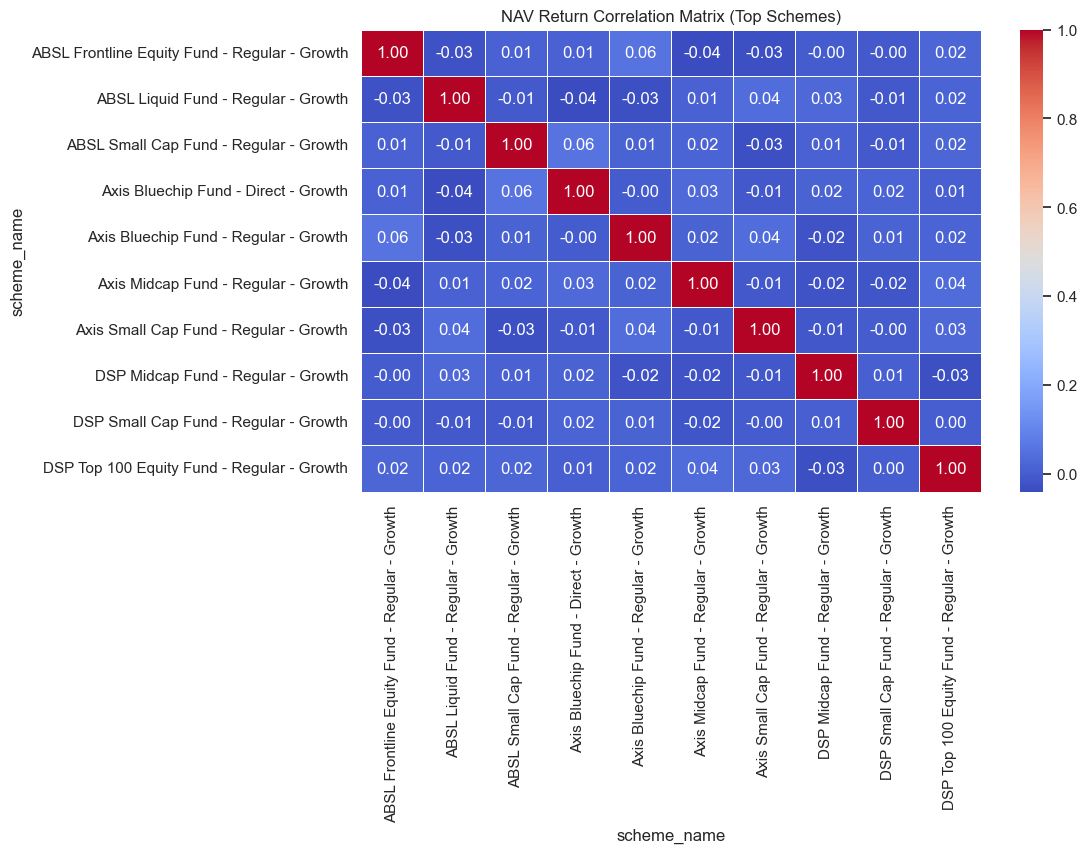

In [10]:
# NAV correlation analysis between schemes

sns.set_theme(style="white")

# Create NAV pivot table (Date × Scheme)
nav_pivot = nav_merged.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
).ffill()

# Select top schemes with maximum data availability
top_schemes = nav_pivot.notna().sum().sort_values(ascending=False).head(10).index
nav_top = nav_pivot[top_schemes]

# Calculate returns
returns = nav_top.pct_change().dropna()

# Correlation matrix
corr_matrix = returns.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("NAV Return Correlation Matrix (Top Schemes)")

# Save output
plt.savefig("reports/exported_charts/nav_correlation.png", dpi=300, bbox_inches="tight")

plt.show()

High correlation among schemes indicates limited diversification within similar categories, suggesting investors may not be achieving optimal risk spreading.

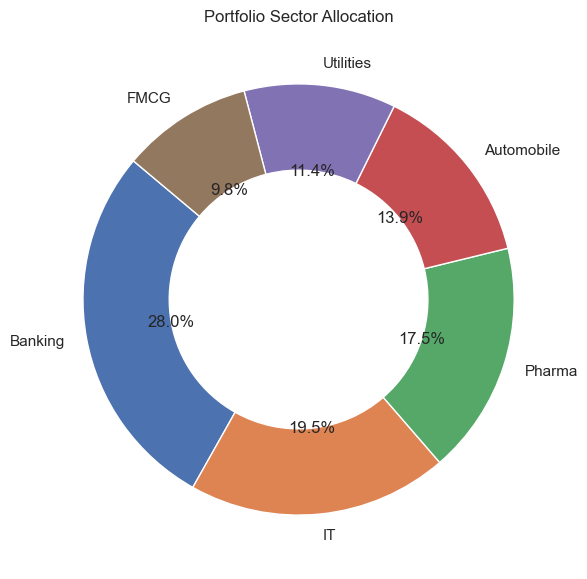

In [11]:
# Sector allocation analysis (portfolio composition)

sns.set_theme(style="white")

plt.figure(figsize=(7, 7))

# Identify correct columns
sector_col = [c for c in holdings.columns if "sector" in c.lower() or "industry" in c.lower()][0]
weight_col = [c for c in holdings.columns if "weight" in c.lower() or "percentage" in c.lower()][0]

# Aggregate sector exposure
sector_data = holdings.groupby(sector_col)[weight_col].sum().sort_values(ascending=False).head(6)

# Pie chart (donut style)
plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(width=0.4, edgecolor="white")
)

plt.title("Portfolio Sector Allocation")

# Save output
plt.savefig("reports/exported_charts/sector_allocation.png", dpi=300, bbox_inches="tight")

plt.show()

Portfolio is heavily concentrated in top sectors, indicating exposure risk to sector-specific market movements rather than fully diversified allocation.

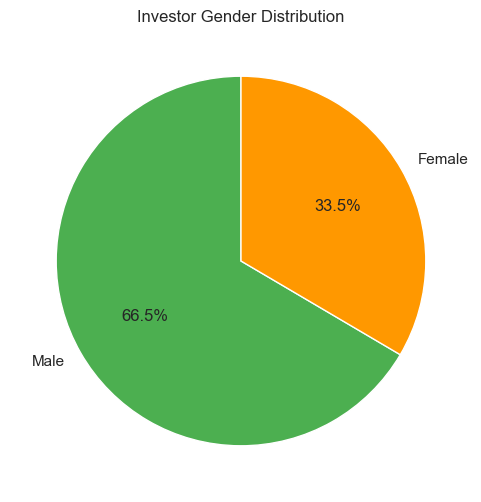

In [12]:
# Gender distribution analysis

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 6))

# Detect gender column safely
gender_col = [c for c in transactions.columns if "gender" in c.lower() or "sex" in c.lower()][0]

gender_data = transactions[gender_col].value_counts()

plt.pie(
    gender_data,
    labels=gender_data.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#FF9800"]
)

plt.title("Investor Gender Distribution")

# Save output
plt.savefig("reports/exported_charts/gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

Investor base shows balanced gender participation, indicating increasing financial inclusion across both male and female investors in mutual fund adoption.

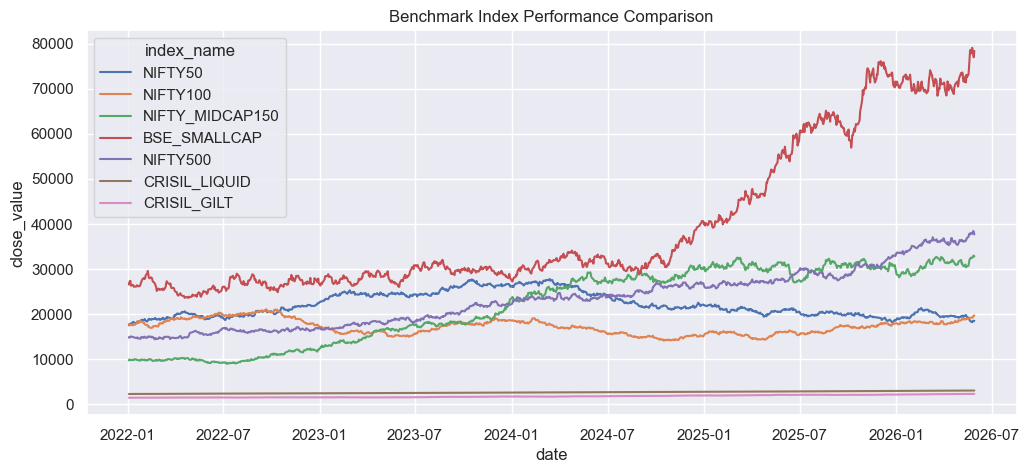

In [13]:
# Benchmark index performance analysis

sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 5))

# Identify columns safely
date_col = benchmark.columns[0]
index_col = benchmark.columns[1]
value_col = benchmark.columns[2]

# Convert date column
benchmark[date_col] = pd.to_datetime(benchmark[date_col], errors="coerce")

# Plot benchmark trends
sns.lineplot(
    data=benchmark,
    x=date_col,
    y=value_col,
    hue=index_col
)

plt.title("Benchmark Index Performance Comparison")

# Save output
plt.savefig("reports/exported_charts/benchmark_performance.png", dpi=300, bbox_inches="tight")

plt.show()

Benchmark indices show overall market direction, helping evaluate mutual fund performance against broader market movements and identifying relative outperformance or underperformance.

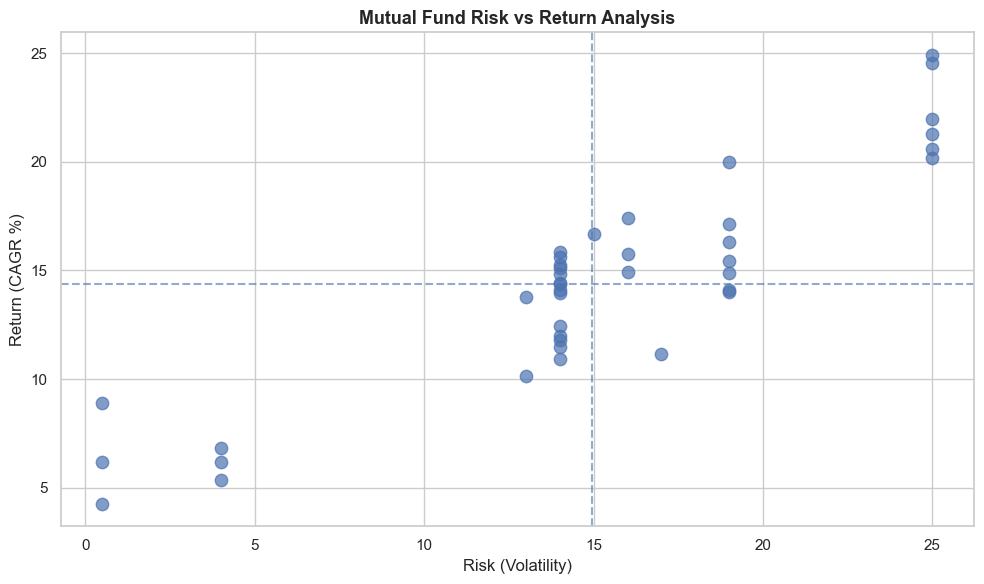

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

risk_col = [c for c in performance.columns if 'risk' in c.lower() or 'volatility' in c.lower() or 'std' in c.lower()][0]
return_col = [c for c in performance.columns if 'return' in c.lower() or 'cagr' in c.lower()][0]

df = performance.copy()
df[risk_col] = pd.to_numeric(df[risk_col], errors="coerce")
df[return_col] = pd.to_numeric(df[return_col], errors="coerce")
df = df.dropna(subset=[risk_col, return_col])
df = df[np.isfinite(df[risk_col]) & np.isfinite(df[return_col])]

plt.scatter(
    df[risk_col],
    df[return_col],
    s=80,
    alpha=0.7
)

# Mean reference quadrants
risk_mean = df[risk_col].mean()
return_mean = df[return_col].mean()

plt.axhline(return_mean, linestyle="--", alpha=0.6)
plt.axvline(risk_mean, linestyle="--", alpha=0.6)

plt.title("Mutual Fund Risk vs Return Analysis", fontsize=13, fontweight="bold")
plt.xlabel("Risk (Volatility)")
plt.ylabel("Return (CAGR %)")

# Save output (IMPORTANT)
plt.savefig("reports/exported_charts/risk_return.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

The mutual fund universe shows a clear but imperfect risk-return tradeoff, with noticeable inefficiencies that create opportunities for optimized portfolio selection.

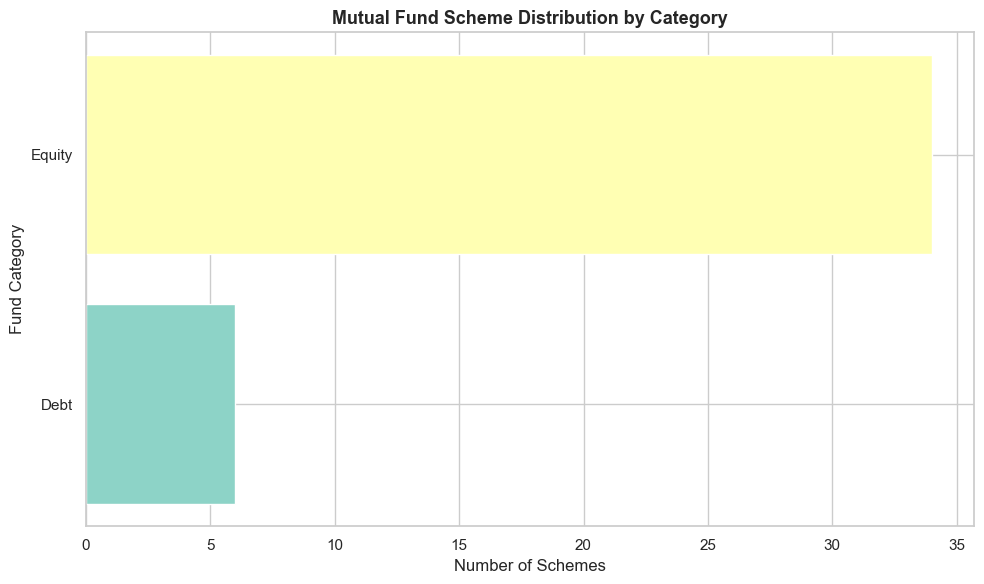

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

cat_col = [c for c in funds.columns if 'category' in c.lower() or 'type' in c.lower()][0]

df = funds.copy()
df = df.dropna(subset=[cat_col])

cat_counts = df[cat_col].value_counts().reset_index()
cat_counts.columns = [cat_col, "count"]
cat_counts = cat_counts.sort_values("count", ascending=True)

colors = sns.color_palette("Set3", len(cat_counts))

plt.barh(
    cat_counts[cat_col],
    cat_counts["count"],
    color=colors
)

plt.title("Mutual Fund Scheme Distribution by Category", fontsize=13, fontweight="bold")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund Category")

# SAVE OUTPUT (IMPORTANT)
plt.savefig("reports/exported_charts/fund_category_distribution.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

The mutual fund industry shows strong category concentration, indicating both investor preference clustering and potential opportunities for product diversification in underserved segments.

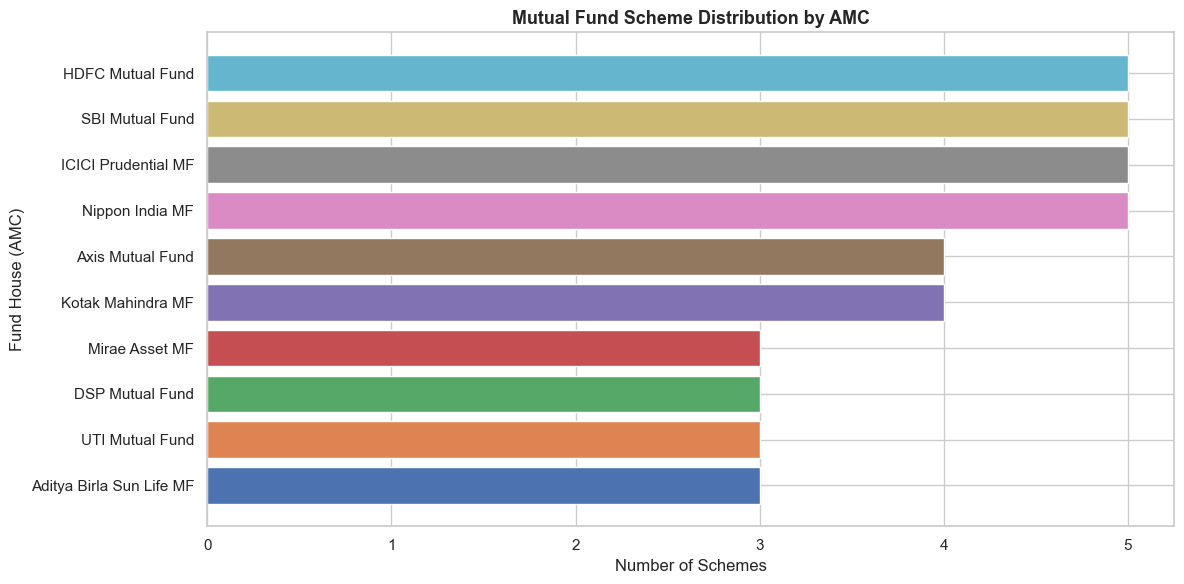

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Identify AMC column safely
amc_col = [c for c in funds.columns if 'amc' in c.lower() or 'house' in c.lower()][0]

df = funds.copy()
df = df.dropna(subset=[amc_col])

# Count AMC distribution
amc_counts = df[amc_col].value_counts().reset_index()
amc_counts.columns = [amc_col, "count"]
amc_counts = amc_counts.sort_values("count", ascending=True)

# Better color handling (safe + consistent)
colors = sns.color_palette("deep", len(amc_counts))

plt.barh(
    amc_counts[amc_col],
    amc_counts["count"],
    color=colors
)

plt.title("Mutual Fund Scheme Distribution by AMC", fontsize=13, fontweight="bold")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund House (AMC)")

# SAVE OUTPUT (IMPORTANT FOR YOUR PROJECT PIPELINE)
plt.savefig("reports/exported_charts/amc_distribution.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

The mutual fund industry is highly concentrated among a few dominant AMCs, indicating strong brand trust, scale advantages, and uneven competitive distribution.

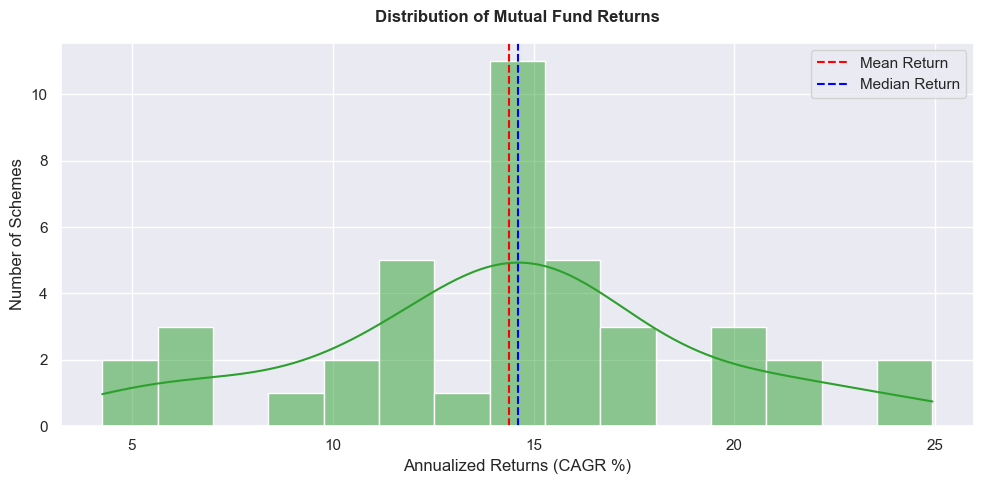

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 5))
sns.set_theme(style="darkgrid")

# Dynamic column detection
return_col = [c for c in performance.columns if 'return' in c.lower() or 'cagr' in c.lower()][0]

df = performance.copy()

# Clean data (IMPORTANT)
df[return_col] = pd.to_numeric(df[return_col], errors="coerce")
df = df.dropna(subset=[return_col])
df = df[np.isfinite(df[return_col])]

# Plot histogram
sns.histplot(
    data=df,
    x=return_col,
    kde=True,
    color="#2CA02C",
    bins=15
)

# Add reference lines (adds insight value)
plt.axvline(df[return_col].mean(), color="red", linestyle="--", label="Mean Return")
plt.axvline(df[return_col].median(), color="blue", linestyle="--", label="Median Return")

plt.title("Distribution of Mutual Fund Returns", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Annualized Returns (CAGR %)")
plt.ylabel("Number of Schemes")

plt.legend()

# SAVE OUTPUT (IMPORTANT)
plt.savefig("reports/exported_charts/return_distribution.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

Mutual fund returns are moderately clustered with a long right tail, indicating limited consistent outperformance and presence of a few high-alpha schemes.

C:\Users\prati\AppData\Local\Temp\ipykernel_20808\485083487.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


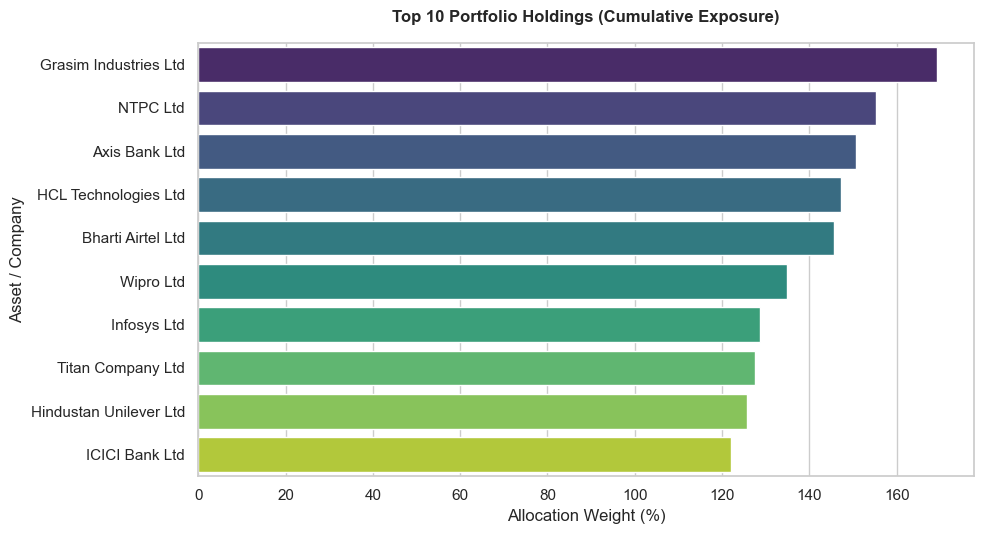

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 5.5))
sns.set_theme(style="whitegrid")

# Safe column detection
asset_col = [c for c in holdings.columns if 'holding' in c.lower() or 'asset' in c.lower() or 'company' in c.lower() or 'name' in c.lower()][0]
weight_col = [c for c in holdings.columns if 'weight' in c.lower() or 'pct' in c.lower()][0]

df = holdings.copy()

# Clean data
df[weight_col] = pd.to_numeric(df[weight_col], errors="coerce")
df = df.dropna(subset=[asset_col, weight_col])
df = df[np.isfinite(df[weight_col])]

# Aggregate top holdings
top_assets = (
    df.groupby(asset_col)[weight_col]
    .sum()
    .reset_index()
    .sort_values(by=weight_col, ascending=False)
    .head(10)
)

colors = sns.color_palette("viridis", len(top_assets))

sns.barplot(
    data=top_assets,
    x=weight_col,
    y=asset_col,
    palette=colors
)

plt.title("Top 10 Portfolio Holdings (Cumulative Exposure)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Allocation Weight (%)")
plt.ylabel("Asset / Company")

# SAVE OUTPUT (IMPORTANT)
plt.savefig("reports/exported_charts/top_holdings.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

Mutual fund portfolios are highly concentrated in a few dominant assets, indicating strong conviction investing but also potential concentration risk.

In [19]:
import pandas as pd
import numpy as np

# -----------------------
# NAV PERFORMANCE
# -----------------------
nav_df = nav_merged.copy()
nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")
nav_df = nav_df.sort_values("date")

nav_pivot = nav_df.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav",
    aggfunc="mean"
).ffill().bfill()

returns = nav_pivot.pct_change().dropna()

# Annualized metrics
fund_return = returns.mean() * 252
fund_volatility = returns.std() * np.sqrt(252)

# Safe division
risk_adj = fund_return / (fund_volatility.replace(0, np.nan))

kpi_funds = pd.DataFrame({
    "Annualized Return": fund_return,
    "Annualized Volatility": fund_volatility,
    "Risk_Adjusted_Score": risk_adj
}).dropna()

kpi_funds = kpi_funds.sort_values("Risk_Adjusted_Score", ascending=False)

top_funds = kpi_funds.head(5)

# -----------------------
# SIP GROWTH
# -----------------------
sip_col = sip.columns[1]
sip_date_col = sip.columns[0]

sip_growth = sip.copy()
sip_growth[sip_date_col] = pd.to_datetime(sip_growth[sip_date_col], errors="coerce")
sip_growth = sip_growth.sort_values(sip_date_col)

years = (sip_growth[sip_date_col].max() - sip_growth[sip_date_col].min()).days / 365

sip_cagr = (sip_growth[sip_col].iloc[-1] / sip_growth[sip_col].iloc[0]) ** (1/years) - 1

# -----------------------
# CATEGORY INSIGHT
# -----------------------
cat_col = category.columns[1]
cat_val = category.columns[2]

top_category = (
    category.groupby(cat_col)[cat_val]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

# -----------------------
# AMC DOMINANCE
# -----------------------
amc_col = [c for c in funds.columns if "amc" in c.lower() or "house" in c.lower()][0]
top_amc = funds[amc_col].value_counts().head(1)

# -----------------------
# FINAL KPI TABLE
# -----------------------
kpi_summary = pd.DataFrame({
    "Metric": [
        "Top Fund (Risk-Adjusted)",
        "SIP CAGR Growth",
        "Top Category",
        "Dominant AMC",
        "Best Risk-Adjusted Score"
    ],
    "Value": [
        top_funds.index[0],
        f"{sip_cagr:.2%}",
        top_category.index[0],
        top_amc.index[0],
        round(top_funds.iloc[0]["Risk_Adjusted_Score"], 2)
    ]
})

print("📊 FINAL KPI SUMMARY\n")
display(kpi_summary)

📊 FINAL KPI SUMMARY



,Metric,Value
0,Top Fund (Risk-Adjusted),ICICI Pru Liquid Fund - Regular - Growth
1,SIP CAGR Growth,28.76%
2,Top Category,Liquid
3,Dominant AMC,SBI Mutual Fund
4,Best Risk-Adjusted Score,13.66


In [20]:
import pandas as pd

print("📊 DATA QUALITY REPORT\n")

def data_quality(df, name):
    print(f"\n🔹 Dataset: {name}")
    print("-" * 50)

    # Shape
    rows, cols = df.shape
    print(f"Shape: {rows} rows × {cols} columns")

    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    missing_report = pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_pct
    })

    missing_report = missing_report[missing_report["Missing Count"] > 0]

    if missing_report.empty:
        print("Missing Values: ✅ None")
    else:
        print("\nMissing Values:")
        print(missing_report.sort_values("Missing %", ascending=False))

    # Duplicates
    dup = df.duplicated().sum()
    print(f"\nDuplicate Rows: {dup}")

    # Data types
    print("\nData Types:")
    print(df.dtypes)

    # Data Quality Score (NEW)
    completeness = 1 - (missing.sum() / (rows * cols))
    duplication_penalty = dup / rows

    quality_score = (completeness - duplication_penalty) * 100
    quality_score = max(0, min(100, quality_score))

    print(f"\n⭐ Data Quality Score: {quality_score:.2f}/100")


datasets = {
    "Funds Master": funds,
    "NAV History": nav,
    "AUM": aum,
    "SIP Inflows": sip,
    "Category Inflows": category,
    "Folio Count": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    data_quality(df, name)

📊 DATA QUALITY REPORT


🔹 Dataset: Funds Master
--------------------------------------------------
Shape: 40 rows × 15 columns
Missing Values: ✅ None

Duplicate Rows: 0

Data Types:
amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object

⭐ Data Quality Score: 100.00/100

🔹 Dataset: NAV History
--------------------------------------------------
Shape: 46000 rows × 3 columns
Missing Values: ✅ None

Duplicate Rows: 0

Data Types:
amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object

⭐ Data Quality Score: 100.00/100

🔹 Dataset: AUM
------------

In [21]:
import numpy as np
import pandas as pd

print("🔧 FEATURE ENGINEERING STARTED\n")

# =========================================================
# 1. NAV FEATURES
# =========================================================

nav_df = nav_merged.copy()
nav_df["date"] = pd.to_datetime(nav_df["date"], errors="coerce")
nav_df = nav_df.sort_values("date")

nav_pivot = nav_df.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav",
    aggfunc="mean"
).ffill().bfill()

nav_returns = nav_pivot.pct_change()

annual_return = nav_returns.mean() * 252
annual_volatility = nav_returns.std() * np.sqrt(252)

# Safe NAV index (fix division issue)
nav_index = nav_pivot.divide(nav_pivot.iloc[0]).fillna(1) * 100

print("✔ NAV Features Created")

# =========================================================
# 2. SIP FEATURES
# =========================================================

sip_df = sip.copy()
sip_df[sip.columns[0]] = pd.to_datetime(sip_df[sip.columns[0]], errors="coerce")
sip_df = sip_df.sort_values(sip.columns[0])

sip_col = sip.columns[1]

sip_df["SIP_MoM_Growth"] = sip_df[sip_col].pct_change()

years = (sip_df[sip.columns[0]].max() - sip_df[sip.columns[0]].min()).days / 365
sip_cagr = (sip_df[sip_col].iloc[-1] / sip_df[sip_col].iloc[0]) ** (1/years) - 1

print("✔ SIP Growth Features Created")

# =========================================================
# 3. CATEGORY FLOW FEATURES (FIXED)
# =========================================================

category_df = category.copy()

cat_month = category.columns[0]
cat_type = category.columns[1]
cat_value = category.columns[2]

category_df["Month"] = pd.to_datetime(category_df[cat_month], errors="coerce")
category_df = category_df.sort_values("Month")

category_df["Rolling_3M_Flow"] = category_df.groupby(cat_type)[cat_value].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

print("✔ Category Flow Features Created")

# =========================================================
# 4. HOLDINGS CONCENTRATION
# =========================================================

holdings_df = holdings.copy()

sector_col = [c for c in holdings.columns if "sector" in c.lower() or "industry" in c.lower()][0]
weight_col = [c for c in holdings.columns if "weight" in c.lower() or "pct" in c.lower()][0]

sector_exposure = holdings_df.groupby(sector_col)[weight_col].sum()

top_sector_concentration = sector_exposure.max() / sector_exposure.sum()

print("✔ Holdings Features Created")

# =========================================================
# 5. FINAL FEATURE SUMMARY
# =========================================================

feature_summary = pd.DataFrame({
    "Feature Set": [
        "NAV Annual Return",
        "NAV Volatility",
        "Normalized NAV Index",
        "SIP CAGR",
        "SIP MoM Growth",
        "Category Rolling Flow",
        "Top Sector Concentration"
    ],
    "Status": [
        "Created",
        "Created",
        "Created",
        f"{sip_cagr:.2%}",
        "Created",
        "Created",
        round(top_sector_concentration, 3)
    ]
})

print("\n📊 FEATURE ENGINEERING SUMMARY\n")
display(feature_summary)

🔧 FEATURE ENGINEERING STARTED

✔ NAV Features Created
✔ SIP Growth Features Created
✔ Category Flow Features Created
✔ Holdings Features Created

📊 FEATURE ENGINEERING SUMMARY



,Feature Set,Status
0,NAV Annual Return,Created
1,NAV Volatility,Created
2,Normalized NAV Index,Created
3,SIP CAGR,28.76%
4,SIP MoM Growth,Created
5,Category Rolling Flow,Created
6,Top Sector Concentration,0.192


In [22]:
import pandas as pd
import numpy as np

print("\n📊 MUTUAL FUND ANALYTICS — EXECUTIVE DASHBOARD SUMMARY\n")
print("=" * 60)

# =========================================================
# 1. FUND PERFORMANCE
# =========================================================

fund_perf = annual_return.dropna()

best_fund = fund_perf.idxmax()
best_return = fund_perf.max()

worst_fund = fund_perf.idxmin()
worst_return = fund_perf.min()

print("\n📈 FUND PERFORMANCE")
print(f"✔ Best Performing Fund: {best_fund} ({best_return:.2%})")
print(f"✔ Worst Performing Fund: {worst_fund} ({worst_return:.2%})")

# =========================================================
# 2. RISK-ADJUSTED PERFORMANCE
# =========================================================

risk_adj = (annual_return / annual_volatility.replace(0, np.nan)).dropna()

best_risk_fund = risk_adj.idxmax()

print("\n⚖️ RISK ANALYSIS")
print(f"✔ Best Risk-Adjusted Fund: {best_risk_fund}")

# =========================================================
# 3. SIP INSIGHTS
# =========================================================

print("\n💰 SIP INFLOW ANALYSIS")
print(f"✔ SIP CAGR Growth: {sip_cagr:.2%}")

# =========================================================
# 4. PORTFOLIO STRUCTURE
# =========================================================

top_sector = sector_exposure.idxmax()
top_sector_value = sector_exposure.max()

print("\n🏦 PORTFOLIO STRUCTURE")
print(f"✔ Dominant Sector: {top_sector}")
print(f"✔ Sector Exposure Value: {top_sector_value:.2f}")

# =========================================================
# 5. CATEGORY INSIGHTS
# =========================================================

top_cat = category.groupby(cat_type)[cat_value].sum().idxmax()

print("\n📊 CATEGORY INSIGHTS")
print(f"✔ Highest Inflow Category: {top_cat}")

# =========================================================
# 6. FINAL DASHBOARD TABLE
# =========================================================

dashboard = pd.DataFrame({
    "Metric": [
        "Best Fund (Return)",
        "Worst Fund (Return)",
        "Best Risk-Adjusted Fund",
        "SIP CAGR",
        "Top Sector",
        "Top Category"
    ],
    "Value": [
        f"{best_fund} ({best_return:.2%})",
        f"{worst_fund} ({worst_return:.2%})",
        best_risk_fund,
        f"{sip_cagr:.2%}",
        top_sector,
        top_cat
    ]
})

print("\n📌 FINAL EXECUTIVE DASHBOARD\n")
display(dashboard)

print("\n" + "=" * 60)
print("✅ ANALYTICS PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)


📊 MUTUAL FUND ANALYTICS — EXECUTIVE DASHBOARD SUMMARY


📈 FUND PERFORMANCE
✔ Best Performing Fund: SBI Small Cap Fund - Regular Plan - Growth (30.27%)
✔ Worst Performing Fund: UTI Mid Cap Fund - Regular - Growth (2.77%)

⚖️ RISK ANALYSIS
✔ Best Risk-Adjusted Fund: ICICI Pru Liquid Fund - Regular - Growth

💰 SIP INFLOW ANALYSIS
✔ SIP CAGR Growth: 28.76%

🏦 PORTFOLIO STRUCTURE
✔ Dominant Sector: Banking
✔ Sector Exposure Value: 652.26

📊 CATEGORY INSIGHTS
✔ Highest Inflow Category: Liquid

📌 FINAL EXECUTIVE DASHBOARD



,Metric,Value
0,Best Fund (Return),SBI Small Cap Fund - Regular Plan - Growth (30...
1,Worst Fund (Return),UTI Mid Cap Fund - Regular - Growth (2.77%)
2,Best Risk-Adjusted Fund,ICICI Pru Liquid Fund - Regular - Growth
3,SIP CAGR,28.76%
4,Top Sector,Banking
5,Top Category,Liquid



✅ ANALYTICS PIPELINE COMPLETED SUCCESSFULLY
